# Publicaciones de Inteligencia Artificial por pa?s (OCDE)

Este cuadernillo genera un mapa mundial de publicaciones de IA por pa?s usando el archivo `Data_2/OECD_AI.csv`. El procedimiento filtra autom?ticamente el ?ltimo a?o disponible en el dataset, agrega los valores por pa?s y construye un mapa coropl?tico con GeoPandas.

Se usa escala logar?tmica porque las diferencias entre pa?ses son muy grandes: China, Estados Unidos e India concentran valores muy superiores al resto. La escala logar?tmica permite ver esa hegemon?a sin que todos los pa?ses de menor producci?n queden visualmente indistinguibles. Para remarcar la concentraci?n, el mapa etiqueta los pa?ses con m?s publicaciones.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("Data_2/OECD_AI.csv")
OUTPUT_DIR = Path("Data_2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120

In [2]:
# Carga y revisi?n general del dataset
raw = pd.read_csv(DATA_PATH)

print(f"Filas: {raw.shape[0]:,}")
print(f"Columnas: {raw.shape[1]:,}")
print(f"A\u00f1os disponibles: {raw['TIME_PERIOD'].min()} - {raw['TIME_PERIOD'].max()}")
print(raw[['REF_AREA', 'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'TIME_PERIOD', 'OBS_VALUE']].head())

Filas: 3,421
Columnas: 41
A?os disponibles: 2000 - 2025
  REF_AREA REF_AREA_LABEL         INDICATOR            INDICATOR_LABEL  \
0      CHN          China  OECD_AI_PUBS_TOT  Number of AI publications   
1      CHN          China  OECD_AI_PUBS_TOT  Number of AI publications   
2      CHN          China  OECD_AI_PUBS_TOT  Number of AI publications   
3      CHN          China  OECD_AI_PUBS_TOT  Number of AI publications   
4      CHN          China  OECD_AI_PUBS_TOT  Number of AI publications   

   TIME_PERIOD    OBS_VALUE  
0         2000   638.583334  
1         2001   831.100001  
2         2002  3143.697621  
3         2003  2822.383338  
4         2004  4152.416669  


In [3]:
# Filtrar publicaciones de IA y usar el ?ltimo a?o disponible
indicator = "OECD_AI_PUBS_TOT"
latest_year = int(raw.loc[raw["INDICATOR"].eq(indicator), "TIME_PERIOD"].max())

pubs = (
    raw.loc[(raw["INDICATOR"].eq(indicator)) & (raw["TIME_PERIOD"].eq(latest_year))]
    .groupby(["REF_AREA", "REF_AREA_LABEL"], as_index=False)["OBS_VALUE"]
    .sum()
    .rename(columns={
        "REF_AREA": "iso3",
        "REF_AREA_LABEL": "country",
        "OBS_VALUE": "ai_publications",
    })
    .sort_values("ai_publications", ascending=False)
    .reset_index(drop=True)
)

print(f"A\u00f1o usado para el mapa: {latest_year}")
print(f"Pa\u00edses con datos: {pubs['iso3'].nunique()}")
pubs.head(15)

A?o usado para el mapa: 2025
Pa?ses con datos: 143


,iso3,country,ai_publications
0,CHN,China,21388.174203
1,USA,United States,7668.714468
2,IND,India,6404.568158
3,KOR,"Korea, Rep.",1811.758257
4,DEU,Germany,1721.604140
5,JPN,Japan,1712.633501
6,GBR,United Kingdom,1624.997664
7,ITA,Italy,1028.584055
8,CAN,Canada,986.536567
9,FRA,France,957.613053


In [4]:
# Cargar geometr?a mundial desde Natural Earth
# ISO_A3_EH se usa porque cubre mejor casos como Francia, Noruega y Taiw?n.
NE_URL = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(NE_URL)
world = world.rename(columns={"ISO_A3_EH": "iso3"})

# Correcciones defensivas para c?digos especiales o ausentes.
fixes = {
    "France": "FRA",
    "Norway": "NOR",
    "Kosovo": "XKX",
    "Somaliland": "SOM",
}
for name, code_iso in fixes.items():
    world.loc[world["NAME"].eq(name), "iso3"] = code_iso

world_map = world.merge(pubs, on="iso3", how="left")
world_map[["NAME", "iso3", "country", "ai_publications"]].head()

,NAME,iso3,country,ai_publications
0,Fiji,FJI,NaN,NaN
1,Tanzania,TZA,Tanzania,14.925532
2,W. Sahara,ESH,NaN,NaN
3,Canada,CAN,Canada,986.536567
4,United States of America,USA,United States,7668.714468


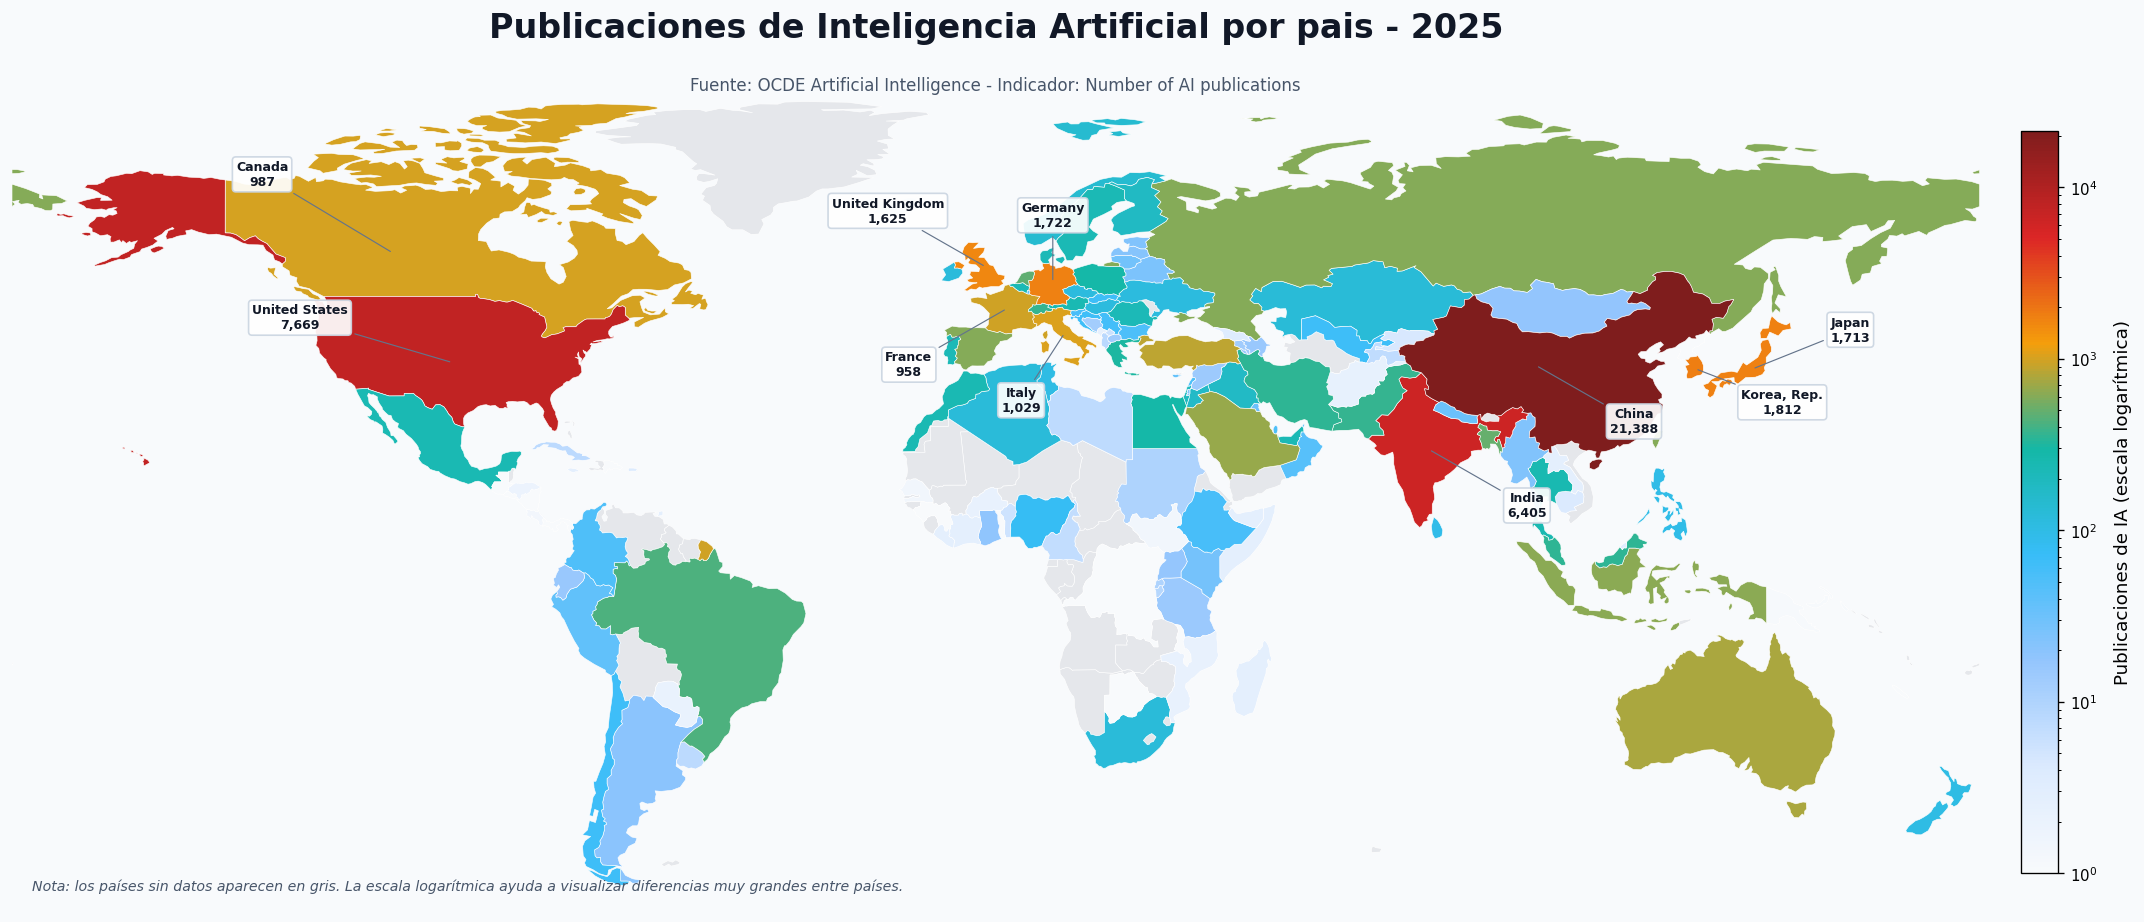

Mapa guardado en: Data_2\mapa_publicaciones_ia_ocde_2025.png


In [8]:
# Generar mapa coropl?tico de publicaciones de IA
positive = pubs.loc[pubs["ai_publications"] > 0, "ai_publications"]
vmin = max(1.0, float(positive.min()))
vmax = float(positive.max())
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

colors_list = [
    "#f8fafc", "#dbeafe", "#93c5fd", "#38bdf8",
    "#14b8a6", "#f59e0b", "#dc2626", "#7f1d1d"
]
cmap = mcolors.LinearSegmentedColormap.from_list("ia_publications", colors_list, N=256)
cmap.set_bad(color="#e5e7eb")

fig, ax = plt.subplots(1, 1, figsize=(18, 10), facecolor="#f8fafc")
ax.set_facecolor("#eef2f7")

# Pa\u00edses base
world_map.plot(ax=ax, color="#e5e7eb", edgecolor="#ffffff", linewidth=0.35)

# Pa\u00edses con datos positivos
has_data = world_map["ai_publications"].notna() & (world_map["ai_publications"] > 0)
world_map.loc[has_data].plot(
    ax=ax,
    column="ai_publications",
    cmap=cmap,
    norm=norm,
    edgecolor="#ffffff",
    linewidth=0.35,
    legend=False,
)

# Barra de color
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02, shrink=0.68)
cbar.set_label("Publicaciones de IA (escala logar\u00edtmica)", fontsize=11, labelpad=10)
cbar.ax.tick_params(labelsize=9)

# Etiquetas para el Top 10
centroids = world_map.loc[has_data].copy()
centroids["point"] = centroids.geometry.representative_point()
centroids = centroids.sort_values("ai_publications", ascending=False).head(10)

label_offsets = {
    "CHN": (18, -10),
    "USA": (-28, 8),
    "IND": (18, -10),
    "KOR": (16, -6),
    "DEU": (0, 12),
    "JPN": (18, 7),
    "GBR": (-18, 10),
    "ITA": (-8, -12),
    "CAN": (-24, 14),
    "FRA": (-18, -10),
    "TUR": (12, -10),
    "AUS": (18, -10),
}

for _, row in centroids.iterrows():
    iso = row["iso3"]
    point = row["point"]
    dx, dy = label_offsets.get(iso, (10, 7))
    label = f"{row['country']}\n{row['ai_publications']:,.0f}"
    ax.annotate(
        label,
        xy=(point.x, point.y),
        xytext=(point.x + dx, point.y + dy),
        fontsize=7.5,
        color="#111827",
        fontweight="bold",
        ha="center",
        va="center",
        arrowprops=dict(arrowstyle="-", color="#64748b", lw=0.7),
        bbox=dict(boxstyle="round,pad=0.28", facecolor="#ffffff", edgecolor="#cbd5e1", alpha=0.92),
    )

ax.set_title(
    f"Publicaciones de Inteligencia Artificial por pais - {latest_year}",
    fontsize=20,
    fontweight="bold",
    color="#111827",
    pad=34,
)
ax.text(
    0.5,
    1.000,
    "Fuente: OCDE Artificial Intelligence - Indicador: Number of AI publications",
    transform=ax.transAxes,
    fontsize=10,
    color="#475569",
    ha="center",
    va="bottom",
)
ax.text(
    0.01,
    0.02,
    "Nota: los pa\u00edses sin datos aparecen en gris. La escala logar\u00edtmica ayuda a visualizar diferencias muy grandes entre pa\u00edses.",
    transform=ax.transAxes,
    fontsize=8.5,
    color="#475569",
    va="bottom",
    fontstyle="italic",
)

ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.axis("off")
plt.tight_layout(rect=[0, 0, 1, 0.94])

output_png = OUTPUT_DIR / f"mapa_publicaciones_ia_ocde_{latest_year}.png"
fig.savefig(output_png, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Mapa guardado en: {output_png}")

In [14]:
# Tabla r?pida para apoyar la interpretaci?n del mapa
top_15 = pubs.head(60).copy()
top_15["participacion_%"] = 100 * top_15["ai_publications"] / pubs["ai_publications"].sum()
top_15[["country", "iso3", "ai_publications", "participacion_%"]]

,country,iso3,ai_publications,participacion_%
0,China,CHN,21388.174203,35.039349
1,United States,USA,7668.714468,12.563333
2,India,IND,6404.568158,10.492336
3,"Korea, Rep.",KOR,1811.758257,2.968128
4,Germany,DEU,1721.604140,2.820432
5,Japan,JPN,1712.633501,2.805736
6,United Kingdom,GBR,1624.997664,2.662166
7,Italy,ITA,1028.584055,1.685086
8,Canada,CAN,986.536567,1.616202
9,France,FRA,957.613053,1.568817
